**Лабораторная работа №1**

Самостоятельно написать код, реализующий искусственный нейрон с сигма-функцией активации, и возможность строить на его основе многослойные сети. Код должен также реализовывать градиентный спуск и обратное распространение ошибки.
На основе вашего кода:

1.	Решить задачу  классификации датаcета Iris одним нейроном.
2.	Решить задачу  классификации датаcета Iris одним  нейросетью из 2 слоев по 10 нейронов в слое.
3.	Отрисовать разделяющую линию для обеих моделей. Сравнить метрики классификации.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

In [2]:
# Функция активации
class Sigmoid:
    @staticmethod
    def forward(x):
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def backward(x, grad_output):
        sig = Sigmoid.forward(x)
        return grad_output * sig * (1 - sig)

In [3]:
# Слой полносвязной сети
class Dense:
    def __init__(self, input_size, output_size, activation=Sigmoid):
        # Инициализация весов
        self.W = np.random.randn(input_size, output_size) * 0.1
        self.b = np.zeros((1, output_size))
        self.activation = activation

        self.X = None
        self.Z = None

    def forward(self, X):
        self.X = X
        self.Z = X @ self.W + self.b
        if self.activation is not None:
            return self.activation.forward(self.Z)
        return self.Z

    def backward(self, grad_output, lr):
        # Градиент по выходу слоя
        if self.activation is not None:
            grad_Z = self.activation.backward(self.Z, grad_output)
        else:
            grad_Z = grad_output

        # Градиенты по весам и смещениям
        dW = self.X.T @ grad_Z / self.X.shape[0]
        db = np.sum(grad_Z, axis=0, keepdims=True) / self.X.shape[0]
        # Градиент для передачи предыдущему слою
        dX = grad_Z @ self.W.T

        # Обновление параметров
        self.W -= lr * dW
        self.b -= lr * db

        return dX

In [4]:
# Функция потерь
class BinaryCrossEntropy:
    @staticmethod
    def forward(y_pred, y_true):
        y_true = y_true.reshape(-1, 1)
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)  # избегаем log(0)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def backward(y_pred, y_true):
        y_true = y_true.reshape(-1, 1)
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        return (y_pred - y_true) / (y_pred * (1 - y_pred)) / y_true.shape[0]

In [5]:
# Нейронная сеть
class NeuralNetwork:
    def __init__(self, layers):
         # Список объектов Dense (без учёта входного слоя)
        self.layers = layers

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, grad_output, lr):
        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad, lr)
        return grad

    def train(self, X, y, epochs, lr, batch_size=32, verbose=True):
        n_samples = X.shape[0]
        loss_history = []
        for epoch in range(epochs):
            # Перемешивание данных
            idx = np.random.permutation(n_samples)
            X_shuffled = X[idx]
            y_shuffled = y[idx]

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                # Прямой проход
                y_pred = self.forward(X_batch)
                # Обратное распространение
                grad = BinaryCrossEntropy.backward(y_pred, y_batch)
                self.backward(grad, lr)

            # Полная потеря
            y_pred_all = self.forward(X)
            loss = BinaryCrossEntropy.forward(y_pred_all, y)
            loss_history.append(loss)
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        return loss_history

    def predict(self, X):
        prob = self.forward(X)
        return (prob >= 0.5).astype(int)

In [6]:
# Подготовка данных
iris = load_iris()
X = iris.data[:, 2:4]  # длина, ширина лепестка
y = iris.target
# setosa - 0, versicolor - 1 (бинарная классификация — без virginica)
mask = y != 2
X = X[mask]
y = y[mask].reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Нормализация данных
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Форма тренировочных данных:", X_train.shape)
print("Форма тестовых данных:", X_test.shape)

Форма тренировочных данных: (70, 2)
Форма тестовых данных: (30, 2)


In [8]:
# Бинарная классификация с помощью одного нейрона
single_neuron = NeuralNetwork([Dense(input_size=2, output_size=1, activation=Sigmoid)])

loss_hist = single_neuron.train(X_train, y_train, epochs=1000, lr=0.1, batch_size=16)

y_pred_train = single_neuron.predict(X_train)
y_pred_test = single_neuron.predict(X_test)

print("\nОдин нейрон:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall   :", recall_score(y_test, y_pred_test))

Epoch 0, Loss: 0.6128
Epoch 100, Loss: 0.1505
Epoch 200, Loss: 0.0871
Epoch 300, Loss: 0.0626
Epoch 400, Loss: 0.0495
Epoch 500, Loss: 0.0413
Epoch 600, Loss: 0.0356
Epoch 700, Loss: 0.0313
Epoch 800, Loss: 0.0280
Epoch 900, Loss: 0.0255

Один нейрон:
Train Accuracy: 1.0
Test Accuracy : 1.0
Precision: 1.0
Recall   : 1.0


In [9]:
# Бинарная классификация с помощью нейросети (2 слоя по 10 нейронов)
two_layer_nn = NeuralNetwork([
    Dense(input_size=2, output_size=10, activation=Sigmoid),
    Dense(input_size=10, output_size=10, activation=Sigmoid),
    Dense(input_size=10, output_size=1, activation=Sigmoid)
])

loss_hist2 = two_layer_nn.train(X_train, y_train, epochs=2000, lr=0.1, batch_size=16)

y_pred_train2 = two_layer_nn.predict(X_train)
y_pred_test2 = two_layer_nn.predict(X_test)

print("\nДвухслойная сеть:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train2))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test2))
print("Precision:", precision_score(y_test, y_pred_test2))
print("Recall   :", recall_score(y_test, y_pred_test2))

Epoch 0, Loss: 0.6989
Epoch 100, Loss: 0.6910
Epoch 200, Loss: 0.6910
Epoch 300, Loss: 0.6906
Epoch 400, Loss: 0.6902
Epoch 500, Loss: 0.6901
Epoch 600, Loss: 0.6892
Epoch 700, Loss: 0.6885
Epoch 800, Loss: 0.6878
Epoch 900, Loss: 0.6867
Epoch 1000, Loss: 0.6852
Epoch 1100, Loss: 0.6822
Epoch 1200, Loss: 0.6785
Epoch 1300, Loss: 0.6729
Epoch 1400, Loss: 0.6635
Epoch 1500, Loss: 0.6479
Epoch 1600, Loss: 0.6207
Epoch 1700, Loss: 0.5732
Epoch 1800, Loss: 0.4951
Epoch 1900, Loss: 0.3884

Двухслойная сеть:
Train Accuracy: 1.0
Test Accuracy : 1.0
Precision: 1.0
Recall   : 1.0


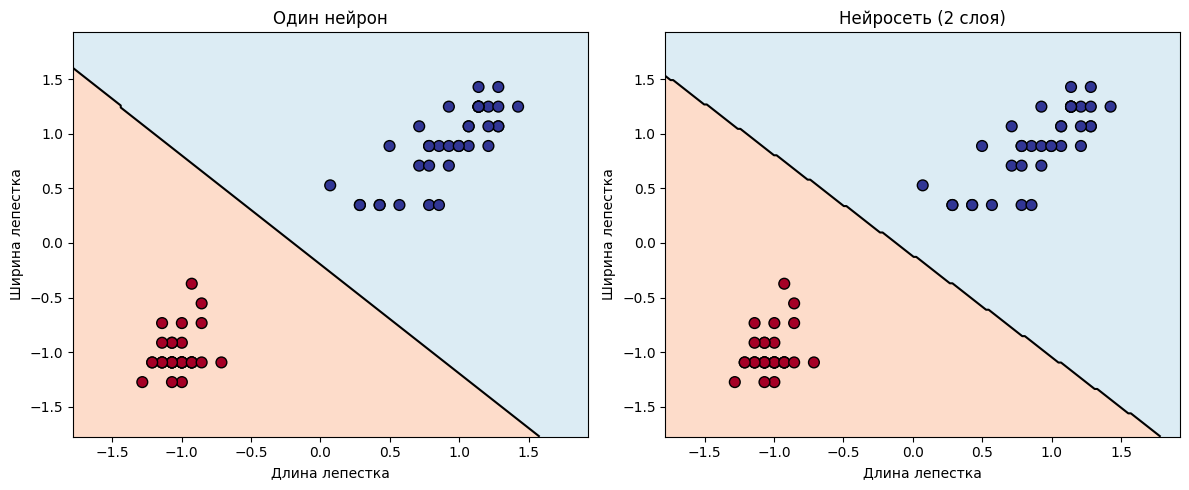

Один нейрон (тест):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        17
  Versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Нейросеть (2 слоя) (тест):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        17
  Versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [10]:
# Визуализация
def plot_decision_boundary(model, X, y, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    # Создание сетки
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.RdYlBu, levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, preds, levels=[0.5], colors='k', linewidths=1.5)

    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='k', cmap=plt.cm.RdYlBu, s=60)
    ax.set_xlabel('Длина лепестка')
    ax.set_ylabel('Ширина лепестка')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(single_neuron, X_train, y_train, 'Один нейрон', ax=axes[0])
plot_decision_boundary(two_layer_nn, X_train, y_train, 'Нейросеть (2 слоя)', ax=axes[1])
plt.tight_layout()
plt.show()

print("Один нейрон (тест):")
print(classification_report(y_test, y_pred_test, target_names=['Setosa', 'Versicolor']))

print("Нейросеть (2 слоя) (тест):")
print(classification_report(y_test, y_pred_test2, target_names=['Setosa', 'Versicolor']))

**Вывод:**

Один нейрон и двухслойная сеть успешно справляются с задачей бинарной классификации, их метрики дают хорошие результаты. Однако двухслойная сеть работает нестабильно: разные запуски дают разные результаты. Также сеть требует значительно больше эпох для обучения, чем один нейрон, и финальная эпоха показала потерю больше, чем один нейрон.

*(Предыдущая попытка:)*

Train Accuracy: 0.9571428571428572

Test Accuracy : 0.9333333333333333

Precision: 0.8666666666666667

Recall   : 1.0

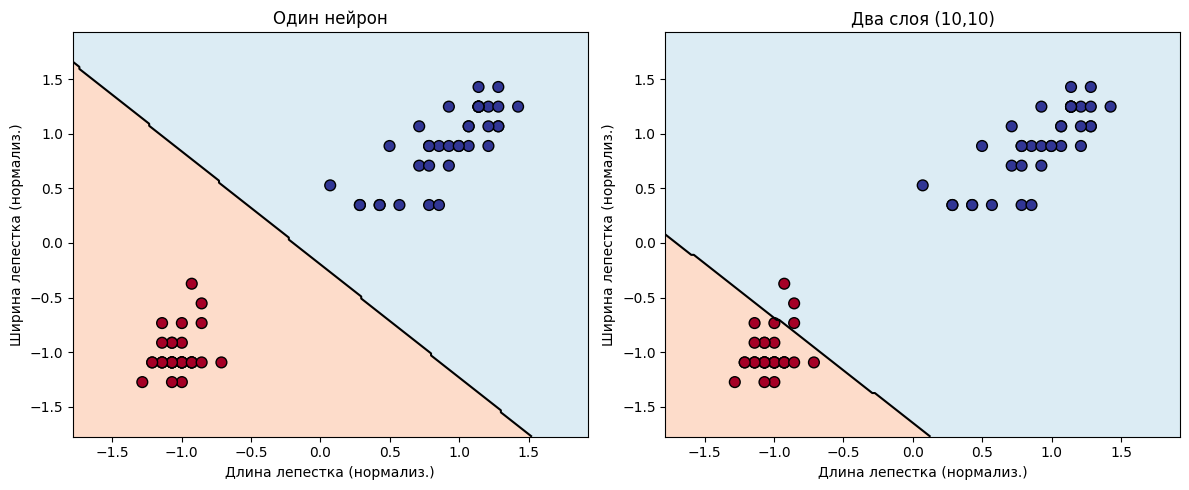